In [5]:
import pandas as pd

df = pd.read_csv('/content/dataset_ML')

df.head()

,order_id,order_status,purchase_date,purchase_year,purchase_month,customer_state,total_items,total_product_value,total_freight_value,avg_item_price,total_payment_value,max_installments,review_score,is_late,delivery_days
0,3e4a8d7b151d4f81900cea441f80d544,delivered,2017-09-08,2017,9,ES,1.0,226.00,26.42,226.000,252.42,3.0,5.0,0,13.0
1,eafa53108733896f6f18e2f8daca6f37,delivered,2018-07-30,2018,7,SP,1.0,159.90,15.43,159.900,175.33,3.0,5.0,0,14.0
2,ad380680e87dea0f2abf5cd5bace626c,shipped,2018-01-21,2018,1,CE,1.0,49.00,25.38,49.000,74.38,1.0,3.0,0,NaN
3,b336214a092c49699b59cfefc4b19ff1,delivered,2018-03-21,2018,3,SP,1.0,47.65,7.71,47.650,55.36,1.0,5.0,0,10.0
4,bce1e6fae8db0875cde2048ee4220438,delivered,2017-12-28,2017,12,MG,2.0,340.63,31.89,170.315,372.52,8.0,5.0,0,11.0


In [6]:
import pandas as pd

df = pd.read_csv('/content/dataset_ML')

df.head()

,order_id,order_status,purchase_date,purchase_year,purchase_month,customer_state,total_items,total_product_value,total_freight_value,avg_item_price,total_payment_value,max_installments,review_score,is_late,delivery_days
0,3e4a8d7b151d4f81900cea441f80d544,delivered,2017-09-08,2017,9,ES,1.0,226.00,26.42,226.000,252.42,3.0,5.0,0,13.0
1,eafa53108733896f6f18e2f8daca6f37,delivered,2018-07-30,2018,7,SP,1.0,159.90,15.43,159.900,175.33,3.0,5.0,0,14.0
2,ad380680e87dea0f2abf5cd5bace626c,shipped,2018-01-21,2018,1,CE,1.0,49.00,25.38,49.000,74.38,1.0,3.0,0,NaN
3,b336214a092c49699b59cfefc4b19ff1,delivered,2018-03-21,2018,3,SP,1.0,47.65,7.71,47.650,55.36,1.0,5.0,0,10.0
4,bce1e6fae8db0875cde2048ee4220438,delivered,2017-12-28,2017,12,MG,2.0,340.63,31.89,170.315,372.52,8.0,5.0,0,11.0


In [7]:
df.isnull().sum().sort_values(ascending=False)

,0
delivery_days,2965
total_product_value,775
total_items,775
total_freight_value,775
avg_item_price,775
review_score,768
total_payment_value,1
max_installments,1
purchase_month,0
customer_state,0


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

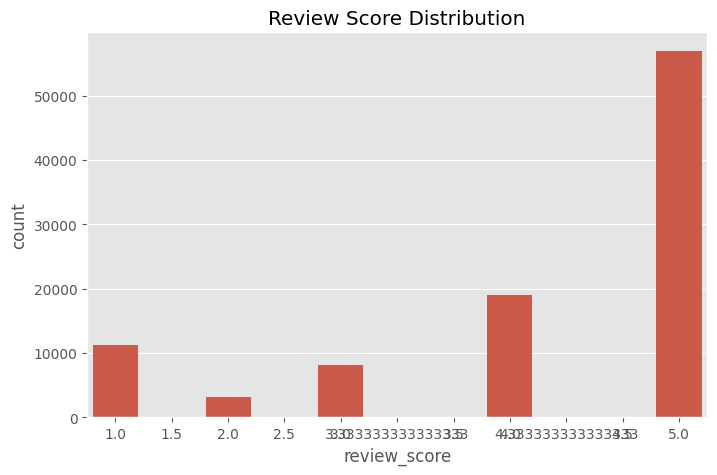

In [9]:
#Review Score Distribution
plt.figure(figsize=(8,5))

sns.countplot(
    x='review_score',
    data=df
)

plt.title('Review Score Distribution')
plt.show()

Insight

*   Review 5 sao chiếm đa số
*   Khách hàng nhìn chung hài lòng




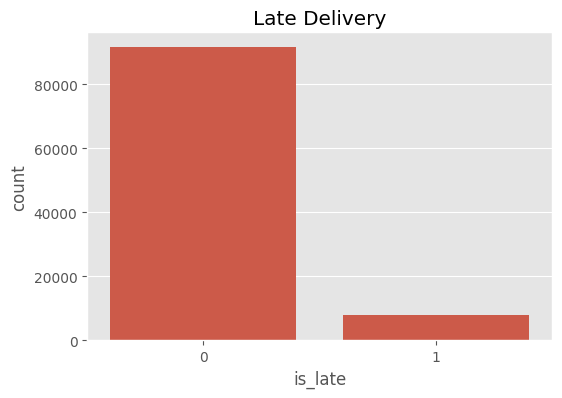

In [10]:
#Late Delivery Distribution
plt.figure(figsize=(6,4))

sns.countplot(
    x='is_late',
    data=df
)

plt.title('Late Delivery')
plt.show()



*   Đơn giao đúng hạn chiếm đa số
*   Tỷ lệ giao trễ thấp




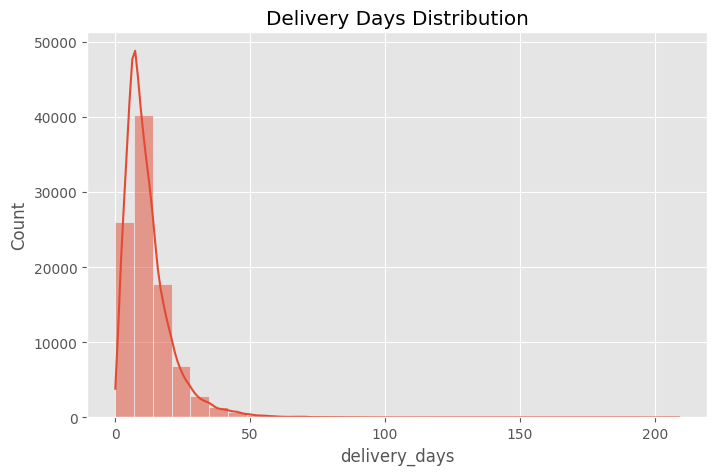

In [11]:
#Delivery Days
plt.figure(figsize=(8,5))

sns.histplot(
    df['delivery_days'],
    bins=30,
    kde=True
)

plt.title('Delivery Days Distribution')
plt.show()



*  Đa số đơn giao từ 5–15 ngày.
*  Đỉnh khoảng 7–10 ngày.
*  Phân phối lệch phải.
*  Có một số đơn giao rất lâu (>50 ngày).



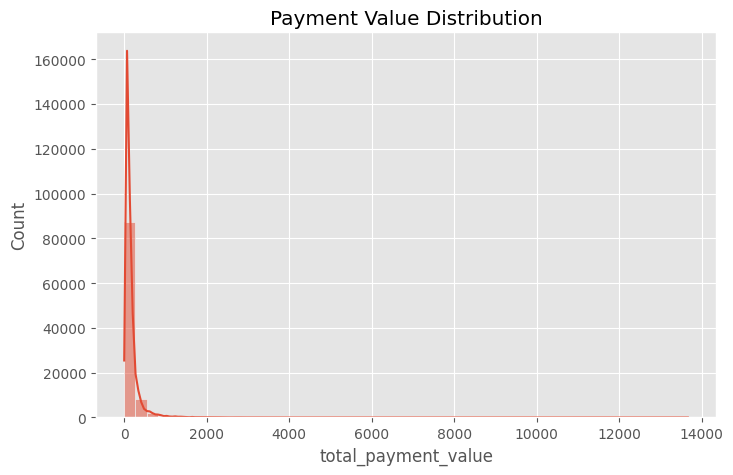

In [13]:
#Payment Value
plt.figure(figsize=(8,5))

sns.histplot(
    df['total_payment_value'],
    bins=50,
    kde=True
)

plt.title('Payment Value Distribution')
plt.show()

Phần lớn đơn hàng có giá trị thấp

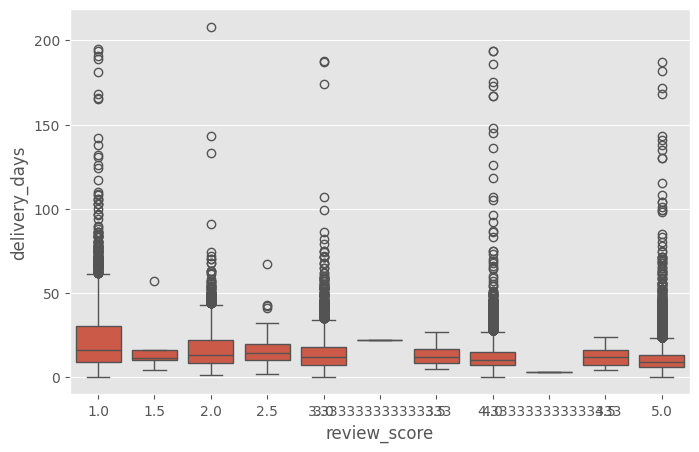

In [15]:
#Review Score vs Delivery Days
plt.figure(figsize=(8,5))

sns.boxplot(
    x='review_score',
    y='delivery_days',
    data=df
)

plt.show()


*   Khách hàng đánh giá 1 sao thường có thời gian giao hàng dài hơn so với các nhóm đánh giá cao. Điều này cho thấy tốc độ giao hàng là một trong những yếu tố ảnh hưởng đến mức độ hài lòng của khách hàng.



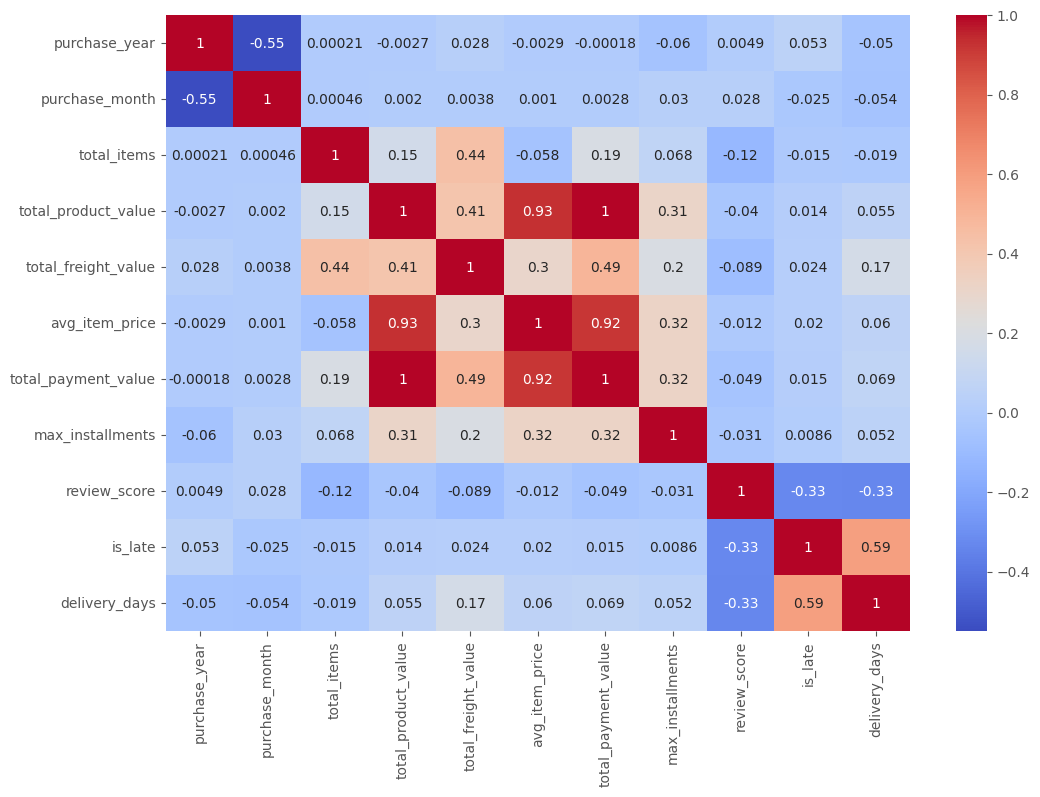

In [16]:
#Correlation Heatmap
numeric_df = df.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

Heatmap cho thấy giá trị sản phẩm là yếu tố ảnh hưởng lớn nhất đến tổng giá trị thanh toán của khách hàng. Về mặt vận hành, thời gian giao hàng và tình trạng giao trễ có mối liên hệ chặt chẽ với điểm đánh giá của khách hàng. Các đơn hàng giao nhanh và đúng hạn thường nhận được đánh giá cao hơn, trong khi giao hàng chậm hoặc trễ làm giảm mức độ hài lòng của khách hàng. Đây là cơ sở để Olist tập trung cải thiện hiệu quả logistics nhằm nâng cao trải nghiệm khách hàng.

# **Chuẩn bị dữ liệu**

In [17]:
df = df.drop(
    columns=[
        'order_id',
        'purchase_date'
    ],
    errors='ignore'
)

In [18]:
df = pd.get_dummies(
    df,
    columns=[
        'customer_state',
        'order_status'
    ],
    drop_first=True
)

In [19]:
#chia x,y
y = df['is_late']

X = df.drop(
    'is_late',
    axis=1
)

In [20]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [21]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

RandomForestClassifier(n_estimators=200, random_state=42)

In [22]:
#predict
y_pred = rf.predict(X_test)

In [23]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Accuracy :", accuracy_score(y_test,y_pred))
print("Precision:", precision_score(y_test,y_pred))
print("Recall   :", recall_score(y_test,y_pred))
print("F1 Score :", f1_score(y_test,y_pred))

Accuracy : 0.9629443410930665
Precision: 0.8490725126475548
Recall   : 0.6434504792332268
F1 Score : 0.7320974191203199


Accuracy đạt 96.29%, cho thấy mô hình dự đoán rất chính xác tổng thể.
Precision đạt 84.91%, nghĩa là khi mô hình dự đoán một đơn sẽ giao trễ thì khoảng 85% trường hợp là đúng.
Recall đạt 64.35%, mô hình vẫn bỏ sót một số đơn giao trễ.
F1 Score đạt 73.21%, thể hiện sự cân bằng khá tốt giữa Precision và Recall.

In [24]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     18324
           1       0.85      0.64      0.73      1565

    accuracy                           0.96     19889
   macro avg       0.91      0.82      0.86     19889
weighted avg       0.96      0.96      0.96     19889



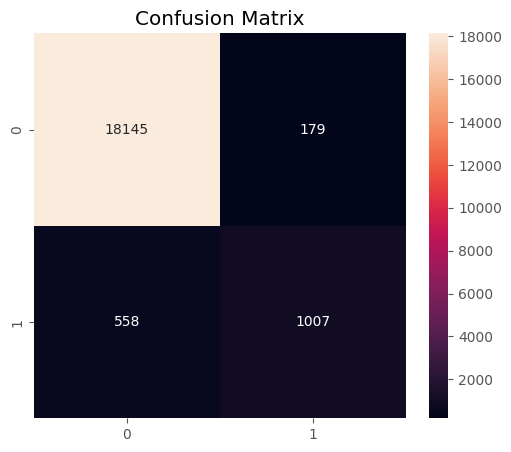

In [25]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title('Confusion Matrix')
plt.show()

In [26]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    'Importance',
    ascending=False
)

importance.head(15)

,Feature,Importance
9,delivery_days,0.465663
8,review_score,0.095920
4,total_freight_value,0.079163
6,total_payment_value,0.069295
5,avg_item_price,0.064126
3,total_product_value,0.063702
1,purchase_month,0.051287
7,max_installments,0.028461
0,purchase_year,0.012308
34,customer_state_SP,0.009183


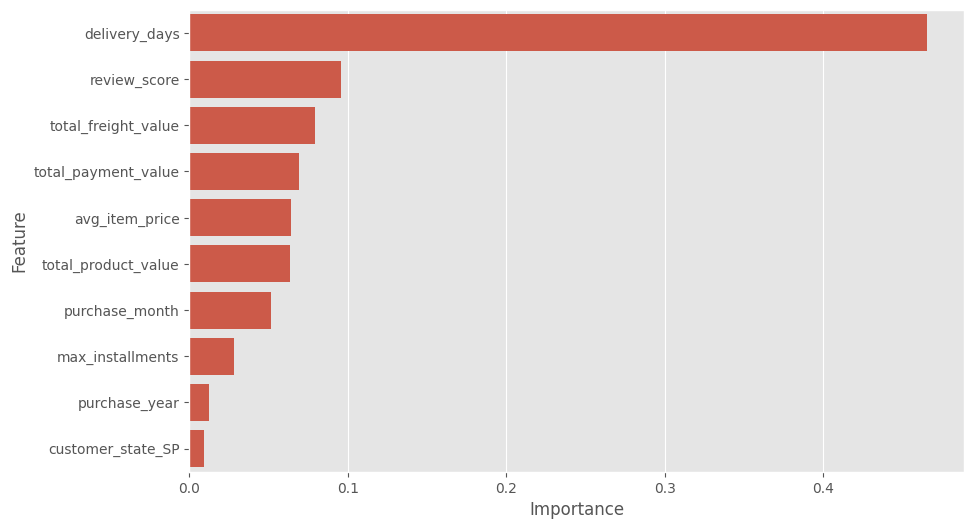

In [27]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x='Importance',
    y='Feature'
)

plt.show()

Mô hình Random Forest đã được xây dựng nhằm dự đoán các đơn hàng có nguy cơ giao trễ trên nền tảng thương mại điện tử Olist. Kết quả cho thấy mô hình đạt độ chính xác (Accuracy) 96.29%, đồng thời xác định được các yếu tố ảnh hưởng lớn nhất đến việc giao hàng trễ bao gồm thời gian giao hàng (Delivery Time), điểm đánh giá của khách hàng (Review Score) và chi phí vận chuyển (Freight Value). Kết quả phân tích cho thấy hiệu suất giao hàng có tác động trực tiếp đến mức độ hài lòng của khách hàng cũng như nguy cơ phát sinh giao hàng trễ. Do đó, doanh nghiệp nên tập trung rút ngắn thời gian giao hàng và tối ưu hóa hoạt động logistics nhằm nâng cao trải nghiệm khách hàng và cải thiện hiệu quả vận hành.